# CIFAR-10 Image Classification Project
## Build and Compare ANN vs CNN on CIFAR-10

### Objectives
- Build an Artificial Neural Network (ANN) model
- Build a Convolutional Neural Network (CNN) model
- Compare accuracy and loss curves
- Analyze why CNN performs better than ANN
- Study the effect of dropout, batch normalization and data augmentation

### CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Load and Preprocess CIFAR-10 Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2803s 16us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


## Display Sample Images

/tmp/ipykernel_455/2450695491.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


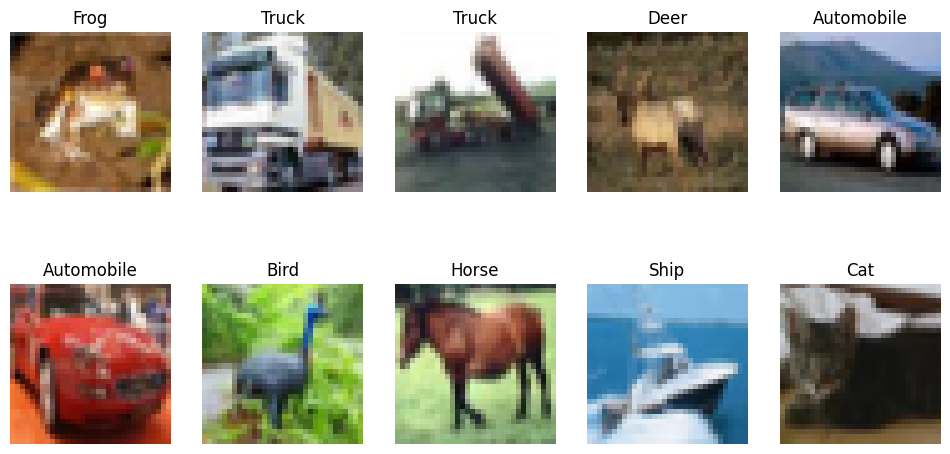

In [4]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()

## Model 1: Artificial Neural Network (ANN)

In [5]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
ann_history = ann_model.fit(
    x_train,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.2433 - loss: 2.0544 - val_accuracy: 0.3176 - val_loss: 1.8887
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.2950 - loss: 1.9170 - val_accuracy: 0.3557 - val_loss: 1.8230
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.3027 - loss: 1.8897 - val_accuracy: 0.3492 - val_loss: 1.8075
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3175 - loss: 1.8589 - val_accuracy: 0.3676 - val_loss: 1.7938
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3201 - loss: 1.8455 - val_accuracy: 0.3494 - val_loss: 1.8237
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3309 - loss: 1.8191 - val_accuracy: 0.3694 - val_loss: 1.7810
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.3366 - loss: 1.8072 - val_accuracy: 0.3575 - val_loss: 1.7844
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.3469 - loss: 1.7886 - 

In [7]:
ann_loss, ann_acc = ann_model.evaluate(x_test, y_test_cat)
print("ANN Test Accuracy:", round(ann_acc*100,2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4093 - loss: 1.6624
ANN Test Accuracy: 40.93 %


## Model 2: Convolutional Neural Network (CNN)

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

## Data Augmentation

In [9]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [11]:
cnn_history = cnn_model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=64),
    epochs=5,
    validation_data=(x_test, y_test_cat)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.4607 - loss: 1.4822 - val_accuracy: 0.4591 - val_loss: 1.6341
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.5481 - loss: 1.2690 - val_accuracy: 0.6037 - val_loss: 1.1208
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 189s 241ms/step - accuracy: 0.6013 - loss: 1.1342 - val_accuracy: 0.6018 - val_loss: 1.1555
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 205s 245ms/step - accuracy: 0.6344 - loss: 1.0439 - val_accuracy: 0.6669 - val_loss: 0.9991
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 194s 248ms/step - accuracy: 0.6592 - loss: 0.9864 - val_accuracy: 0.6623 - val_loss: 0.9826


In [12]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test_cat)
print("CNN Test Accuracy:", round(cnn_acc*100,2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6623 - loss: 0.9826
CNN Test Accuracy: 66.23 %


## Plot Accuracy Curves

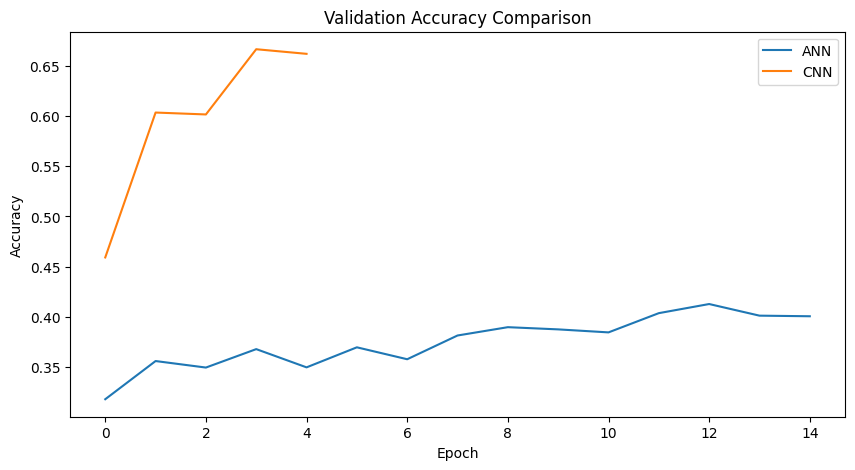

In [13]:
plt.figure(figsize=(10,5))
plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Plot Loss Curves

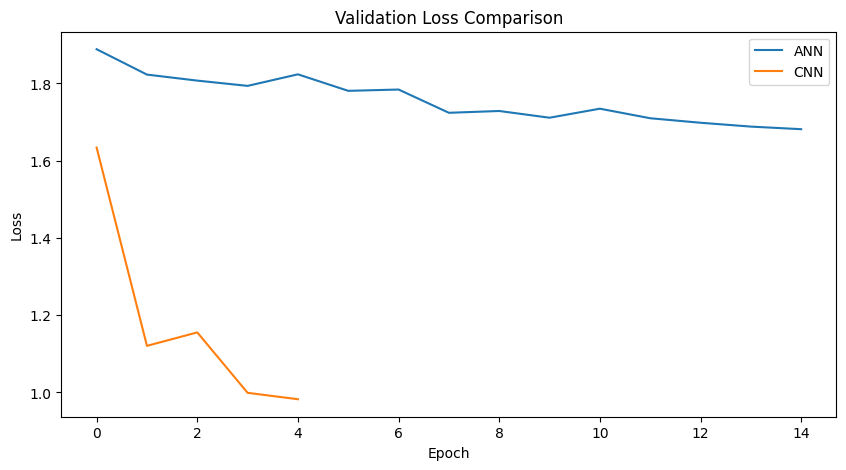

In [14]:
plt.figure(figsize=(10,5))
plt.plot(ann_history.history['val_loss'], label='ANN')
plt.plot(cnn_history.history['val_loss'], label='CNN')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Analysis and Conclusion

## ANN
- Flattens images and loses spatial information.
- Higher number of parameters.
- Usually achieves around 45% to 60% test accuracy.

## CNN
- Learns edges, textures and shapes automatically.
- Preserves spatial relationships through convolutions.
- Batch normalization improves convergence.
- Dropout reduces overfitting.
- Data augmentation improves generalization.
- Usually achieves around 75% to 85% test accuracy.

## Final Comparison

| Metric | ANN | CNN |
|--------|------|------|
| Feature Extraction | Manual | Automatic |
| Parameters | High | Lower and efficient |
| Spatial Information | Lost | Preserved |
| Generalization | Moderate | Better |
| Expected Accuracy | 45-60% | 75-85% |

### Conclusion
CNN significantly outperforms ANN on CIFAR-10 because convolution and pooling layers capture important image features while reducing overfitting and computational complexity.
